<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [5]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [9]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [10]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [11]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [12]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [13]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [14]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [15]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [16]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [17]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [18]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [19]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

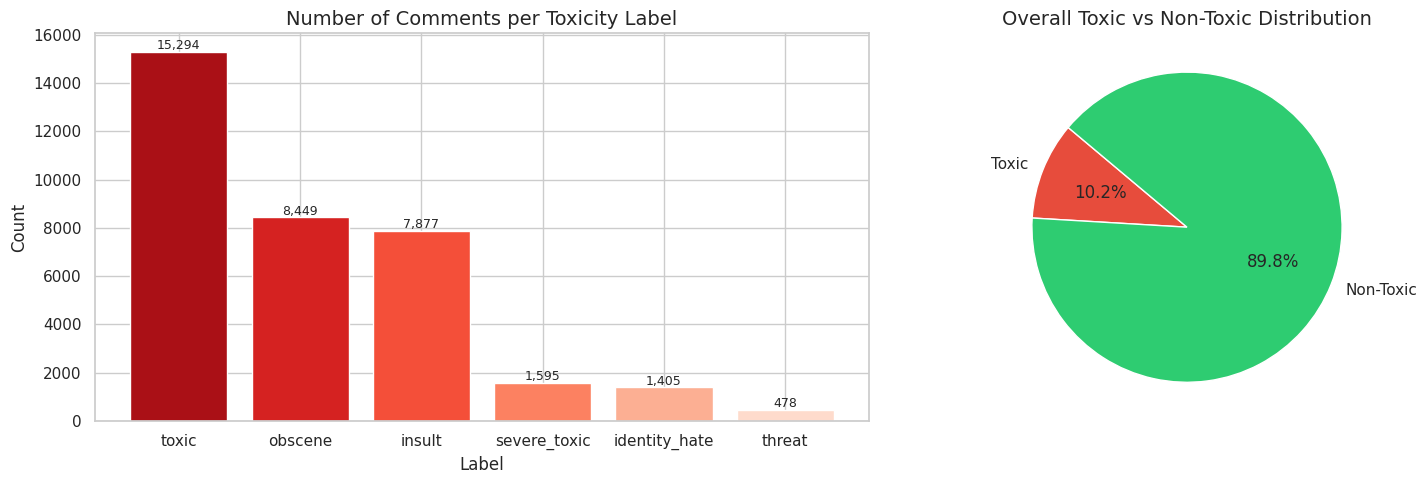

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [21]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

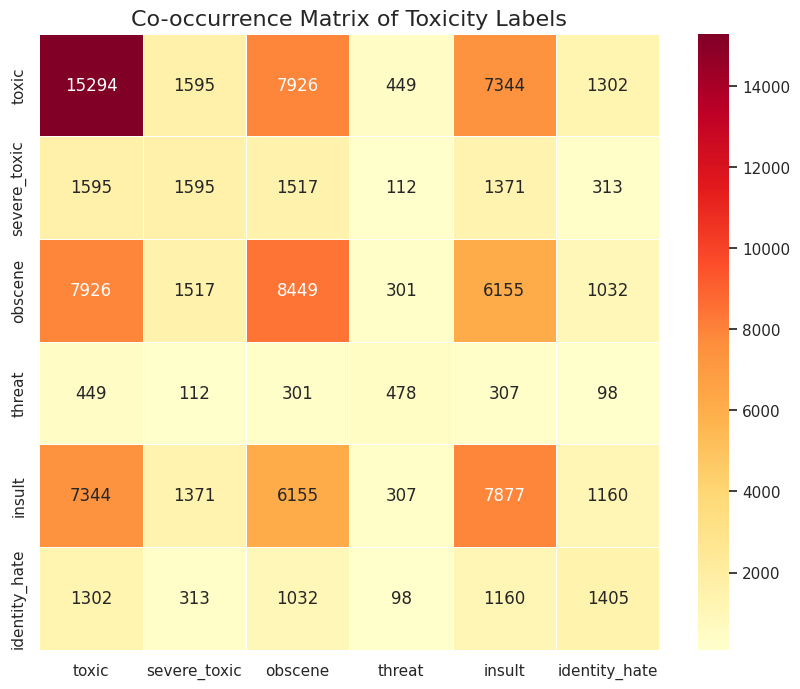

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

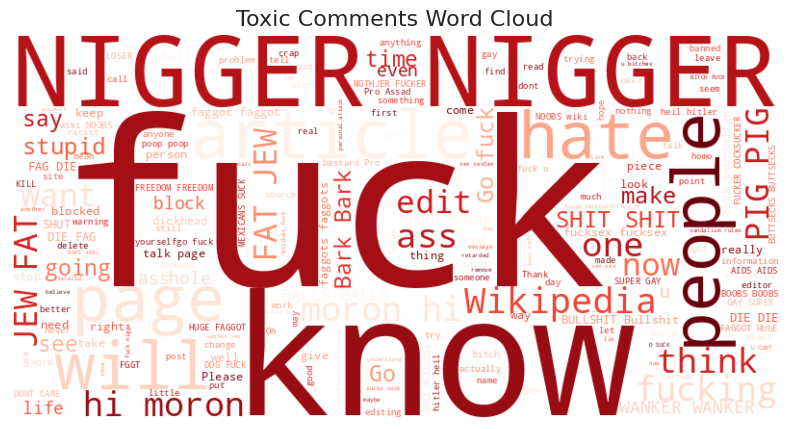

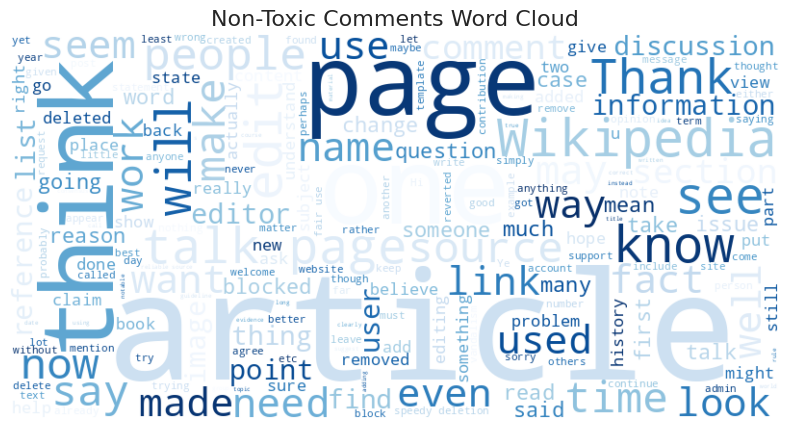

In [23]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

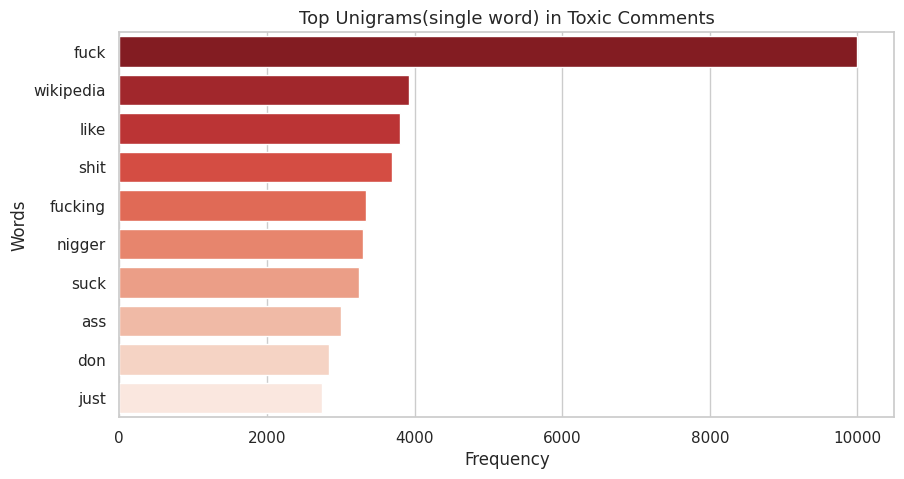

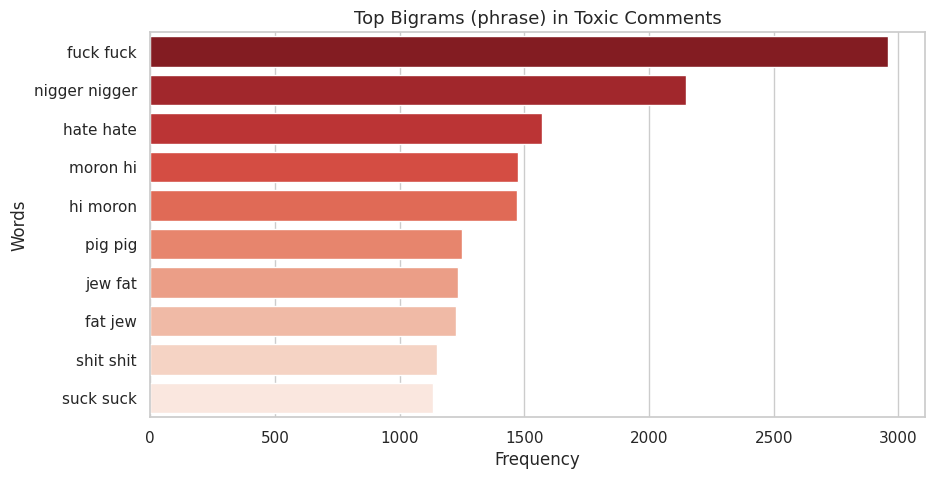

In [24]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [25]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
14380,"""\n\n Your comment in the Serbian-Americans ta...",0
7794,"NP, boo-boo's happen. Done my own fair share o...",0
73366,Yet the SFA have been one of the bodies heavil...,0
73894,"""\n\n Richard Landis \n\n""""Is it possible to w...",0
108427,"""\nWe have """"The hoard was buried as an oak bo...",0
11230,citing sources \n\neverything added to wikiped...,1


**Basic Preprocessing**



1.   Lower case




In [26]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [27]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [28]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [29]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [30]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [31]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [32]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.9 MB/s eta 0:00:00


1. Emoji to text

In [33]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [34]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [35]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [36]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [37]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [38]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [39]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [40]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [41]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [42]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [43]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [44]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [45]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [46]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
12792,"""::Rather vague apology that does not actually mention Ashley Madison. He could be confessing to thinking about infidelity for all I can tell. Look up Exodus 20:17. 63 \n"""
132368,"Hello, you left me a message about my edit being incorrect, but the quote that was there was incorrect. I corrected it and I cited the article where the quote came from\n\nWhat is the problem?\n\nAlso, how do I reply to your message, all I see is this 'talk' page"
68170,Have now fixed a lot of problems
31778,"MfD nomination of Draft:C-Real\nDraft:C-Real, a page you substantially contributed to, has been nominated for deletion. Your opinions on the matter are welcome; please participate in the discussion by adding your comments at Wikipedia:Miscellany for deletion/Draft:C-Real and please be sure to sign your comments with four tildes (~~~~). You are free to edit the content of Draft:C-Real during the discussion but should not remove the miscellany for deletion template from the top of the page; such a removal will not end the deletion discussion. Thank you."
98003,", 6 March 2007 (UTC)\n\nThe Talk page for the infobox contains lots of discussion related to the development of the infobox, who it should be applied to, and what terms should be used. As the infobox then was being applied all eligible articles, Akradecki objected to Shane and Siebold, apparently based on his personal opinion as to who should be classified as an astronaut. He posted his opionion on Talk:Astronaut. I responded and he, I and one other editor engaged in a non-conclusive discussion. 15:40"


Applying Basic Preprocessing

In [47]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
11580,bring it i pit sourcesmy yearbooks
8392,in african cultures most men swing and exit due to lack of water and sanitation hand washing is not an option unlike the sanitation opportunities offered to the male africanamerican population the above statement is blatantly racist it has no business being in wikipedia someone with a better knowledge of wikipedia should clean it up pardon the pun
100849,and dont forget a certain mr c who was involved in sexual harrasment
130298,stylebackgroundcolorffffa padding cellpadding styleborderpx solid backgroundcolorffffa verticalaligntop color hello welcome to wikipedia thank you for your contributions to this free encyclopedia if you decide that you need help check out getting help below ask me on or place on your talk page and ask your question there please remember to sign your name on talk pages by clicking or using four tildes this will automatically produce your username and the date finally please do your best to always fill in the edit summary field below are some useful links to facilitate your involvement happy editing
121354,utc on a similar note do we have a source for this spino in jp thing its the first ive heard of it march


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [48]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
122217,"He told me to not comment on his talkpage, so I was just being an idiot and doing the same, sorry about that.",he told me to not comment on his talkpage so i was just being an idiot and doing the same sorry about that
42913,"""\n\nIllogical statement\n\n""""While slavery is illegal in Saudi Arabia despite Shaykh al-Fawzaan's fatwa, the proclamation carries weight among many Salafi Muslims. According to reformist jurist and author Khaled Abou El Fadl, it 'is particularly disturbing and dangerous because it effectively legitimates...""""\n\nIf it's illegal then what is """"despite"""" in reference to? What in the world is """"particularly dangerous""""???""",illogical statement while slavery is illegal in saudi arabia despite shaykh alfawzaans fatwa the proclamation carries weight among many salafi muslims according to reformist jurist and author khaled abou el fadl it is particularly disturbing and dangerous because it effectively legitimates if its illegal then what is despite in reference to what in the world is particularly dangerous
46319,"""\n\n ZP5 \n\nZP5 is, in my opinion, a waste of time for GW related articles. He calmed down somewhat after his block, but is back to """"normal"""" now. In the absence of admin action, I fear that the RFC route is inevitable. Comments? """,zp zp is in my opinion a waste of time for gw related articles he calmed down somewhat after his block but is back to normal now in the absence of admin action i fear that the rfc route is inevitable comments
62232,"2010 (UTC)\n\nList of war apology statements issued by Japan. I think Japan has apologized many times... What do you need more...? Being Japanese myself, I do not understand what the Korean people want Japan to do... 08:43, 3 March",utc list of war apology statements issued by japan i think japan has apologized many times what do you need more being japanese myself i do not understand what the korean people want japan to do march
8841,"""\n\n 1 year \n\n04:25, 10 April 2006 Linuxbeak (Talk | contribs | block) changed rights for User:Tawker from (none) to (none) (+sysop) \nHappy sysop-ship anniversery! (a wee-bit late) '''''' talk """,year april linuxbeak talk contribs block changed rights for usertawker from none to none sysop happy sysopship anniversery a weebit late talk


Applying Advanced Preprocessing

In [49]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [50]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
149894,alfred tinnenbaum hiplease look article alfred tinnenbaum think hoax done college student nothing came alfred tinnenbaum google working iowa territory article would come across hope well
135137,full documented list muslim author wrote black cursed slavery noah curse ham actually go way time prophet ibn ata according source present article far dispute documented teaching mediaeval muslim scholar seem arguing obligation report fact doesnt fit teaching way wikipedia work mediaeval muslim scholar taught thing documented allowed say mediaeval muslim scholar taught thing documented talk
29511,think expanded explanation clearer would flavor added article
137214,rfa thanks hey lid thank supporting recent rfa finished amazing final tally really appreciate support cheer talk
155659,antiquity greek used term refer foreigner


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [51]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
32994,"""\n\n User name \n\n Hello, and welcome to Wikipedia. I noticed that your username, Official Iowa State Fair, may not meet Wikipedia's username policy because it it represents an organization rather than an individual. If you believe that your username does not violate our policy, please leave a note here explaining why. As an alternative, you may file for a change of username, or you may simply create a new account and use that for editing. Thank you. ChatMe!ReadMe!! """,user name hello welcome wikipedia noticed username official iowa state fair may meet wikipedias username policy represents organization rather individual believe username violate policy please leave note explaining alternative may file change username may simply create new account use editing thank chatmereadme
133539,"""\n\n This user is denying facts from being posted possibly due to political bias. \n\nWhy do you keep on deleting my adding of Victor Vancier under """"Jewish terrorism""""??\n\nHe was sent to jail for terrorism for crying out loud!\n\nLet me guess: you're a fellow JTF Kahanist member who is focused on hiding these facts from the public?\n\nIf you delete it again and falsely call it """"vandalism"""", I will take it to be reviewed and make a complaint against you for political activism on Wikipedia. )""",user denying fact posted possibly due political bias keep deleting adding victor vancier jewish terrorism sent jail terrorism cry loud let guess fellow jtf kahanist member focused hiding fact public delete falsely call vandalism take reviewed make complaint political activism wikipedia
45943,So please state you withdraw it at the FAC and regroup to another peer review and request for copyediting.,please state withdraw fac regroup another peer review request copyediting
88010,", Pala Empire, Rajput period, Magadha Empire",pala empire rajput period magadha empire
36933,"http://en.wikipedia.org/wiki/User:Jonathunder\n\nhttp://en.wikipedia.org/w/index.php?title=User_talk:Where&action;=edit&section;=3\n\nWikipedia:No confidence\nEdicts from above are a growing concern for those who believe Wikipedia should be what it purports itself to be in newspapers, magazines, and to new members: a community of editors. As a community, we believe that members who have greater power should use that power to promote consensus and a neutral point of view. When an administrator abuses his or her greater power to promote self interest or personal POV against or without the consent of the community, we believe that member should lose his or her administrative or higher powers. Would you be interested in starting and/or promoting a Wikipedia:No confidence area for the purpose of demoting administrators and above who use their power to push personal POV?\n\nIn such an area, any editor could call for a show of support or no-confidence for an administrator or higher. People would sign for either support or no-confidence along with examples of the editor in question creating an edict without consensus, or a statement of why they believe the alleged edicts are in line with community consensus. Please feel free to start or add to Wikipedia:No confidence and to duplicate this message or tell other editors who want to see Wikipedia succeed. KIMP (spewage)",wikipediano confidence edict growing concern believe wikipedia purport newspaper magazine new member community editor community believe member greater power use power promote consensus neutral point view administrator abuse greater power promote self interest personal pov without consent community believe member lose administrative higher power would interested starting andor promoting wikipediano confidence area purpose demoting administrator use power push personal pov area editor could call show support noconfidence administrator higher people would sign either support noconfidence along example editor question creating edict without consensus statement believe alleged edict line community co

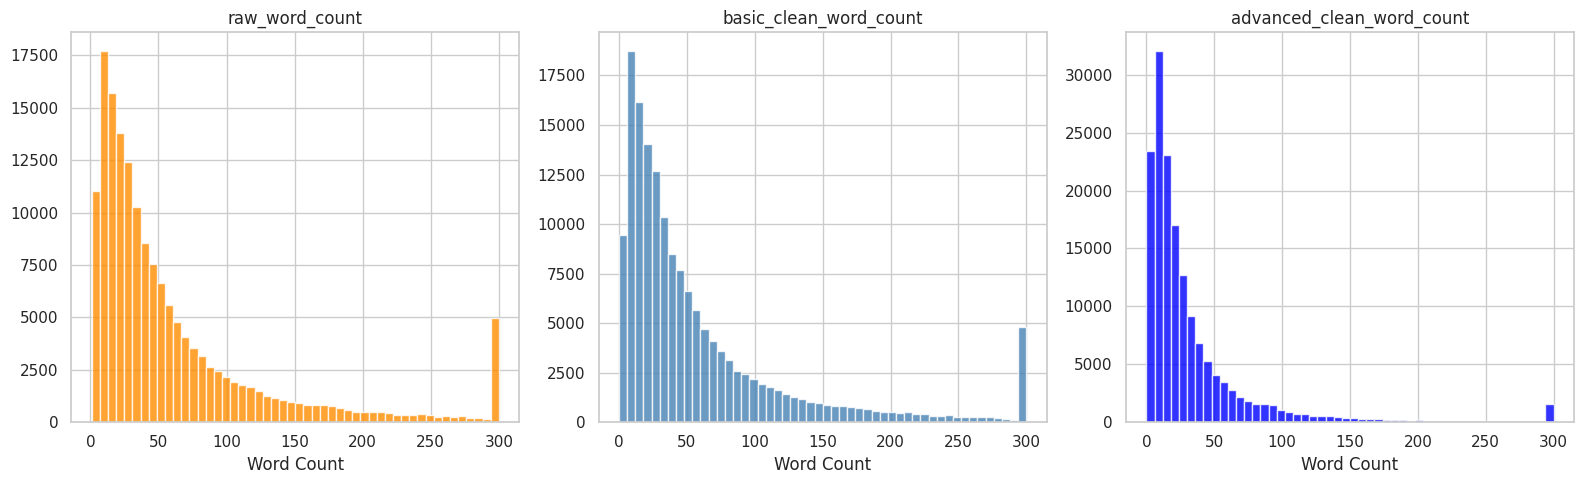

In [52]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [54]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [55]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [57]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [59]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [60]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [62]:
Vocab_size =30000
max_len= 200

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [63]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 200)
LSTM shape val (15957, 200)
LSTM shape test (15958, 200)


3. BERT Tokenizer (for BERT) \
raw dataset

In [64]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [65]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [66]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [98]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [95]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# results = {}

# def evaluate(model_name, y_true, y_pred, y_prob=None,
#              elapsed_train=None, elapsed_infer=None):

#     acc = accuracy_score(y_true, y_pred)

#     prec = precision_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     rec = recall_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     macro_f1 = f1_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     weighted_f1 = f1_score(
#         y_true, y_pred,
#         average='weighted',
#         zero_division=0
#     )

#     # ROC-AUC
#     if y_prob is not None:
#         roc_auc = roc_auc_score(
#             y_true,
#             y_prob,
#             average='macro'
#         )
#     else:
#         roc_auc = None

#     results[model_name] = {
#         'accuracy': round(acc, 4),
#         'precision': round(prec, 4),
#         'recall': round(rec, 4),
#         'macro f1': round(macro_f1, 4),
#         'weighted f1': round(weighted_f1, 4),
#         'roc-auc': round(roc_auc, 4) if roc_auc else '-',
#         'train time (s)': round(elapsed_train, 1) if elapsed_train else '-',
#         'infer time (s)': round(elapsed_infer, 1) if elapsed_infer else '-'
#     }

#     print(f'\n===== {model_name} =====')
#     print(f'Accuracy     : {acc:.4f}')
#     print(f'Precision    : {prec:.4f}')
#     print(f'Recall       : {rec:.4f}')
#     print(f'Macro F1     : {macro_f1:.4f}')
#     print(f'Weighted F1  : {weighted_f1:.4f}')

#     if roc_auc is not None:
#         print(f'ROC-AUC      : {roc_auc:.4f}')

#     if elapsed_train:
#         print(f'Train time   : {elapsed_train:.1f}s')

#     return results[model_name]

In [68]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [69]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [70]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 18.0s


In [71]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 96.38%
obscene: 99.99%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.84%
severe_toxic: 82.45%
obscene: 96.65%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [99]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 7.1s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 7.1,
 'infer time (s)': 0.0}

In [97]:
# y_prob_raw = lr_raw.predict_proba(X_test_tfidf_raw)

# evaluate(
#     'TF-IDF + LR (raw)',
#     y_test.values,
#     y_pred_raw,
#     y_prob=y_prob_raw,
#     elapsed_train=train_t,
#     elapsed_infer=infer_t
# )


===== TF-IDF + LR (raw) =====
Accuracy     : 0.9204
Precision    : 0.8366
Recall       : 0.3936
Macro F1     : 0.5099
Weighted F1  : 0.6726
ROC-AUC      : 0.9775
Train time   : 7.1s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'macro f1': 0.5099,
 'weighted f1': 0.6726,
 'roc-auc': np.float64(0.9775),
 'train time (s)': 7.1,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

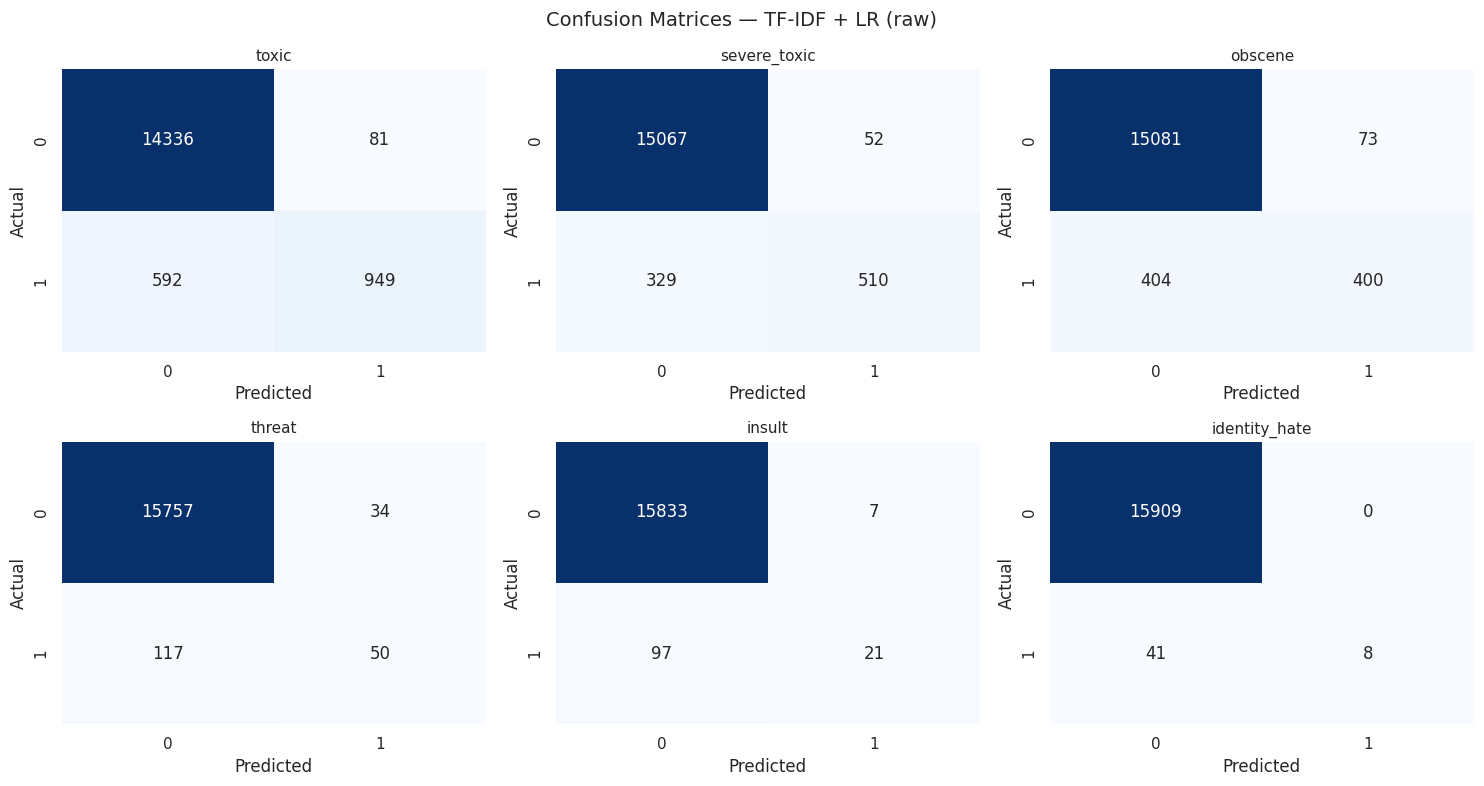

In [73]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [74]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 11.5s


In [100]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 7.1s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 7.1,
 'infer time (s)': 0.0}

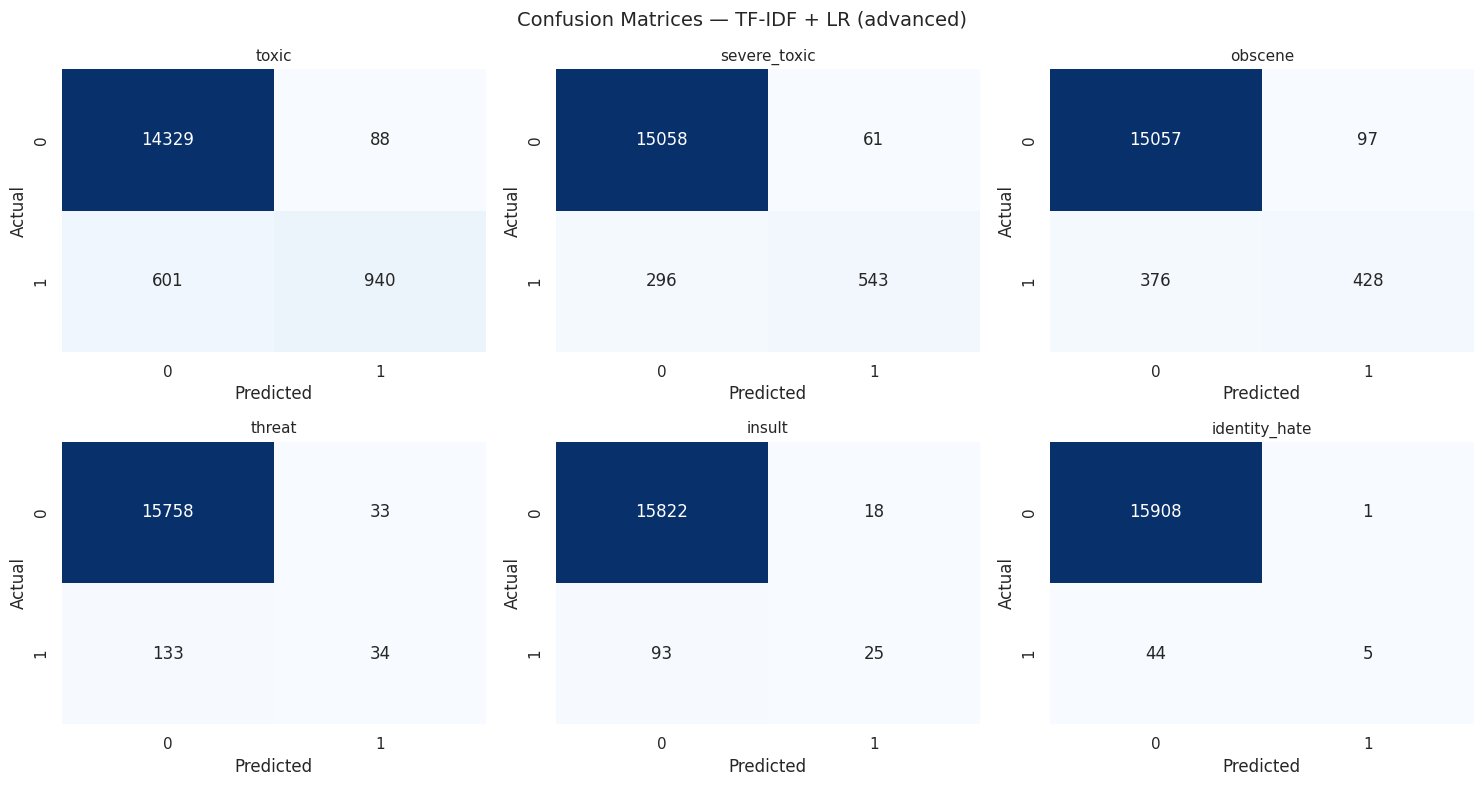

In [76]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [77]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.77%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.96%
severe_toxic: 89.89%
obscene: 98.20%

Comment: Amazing work
Prediction: Non-toxic


# **Model 2 — TF-IDF + SVM (LinearSVC)**

**Raw version **

In [80]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [82]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 30.0s


In [83]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 30.0s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 30.0,
 'infer time (s)': 0.1}

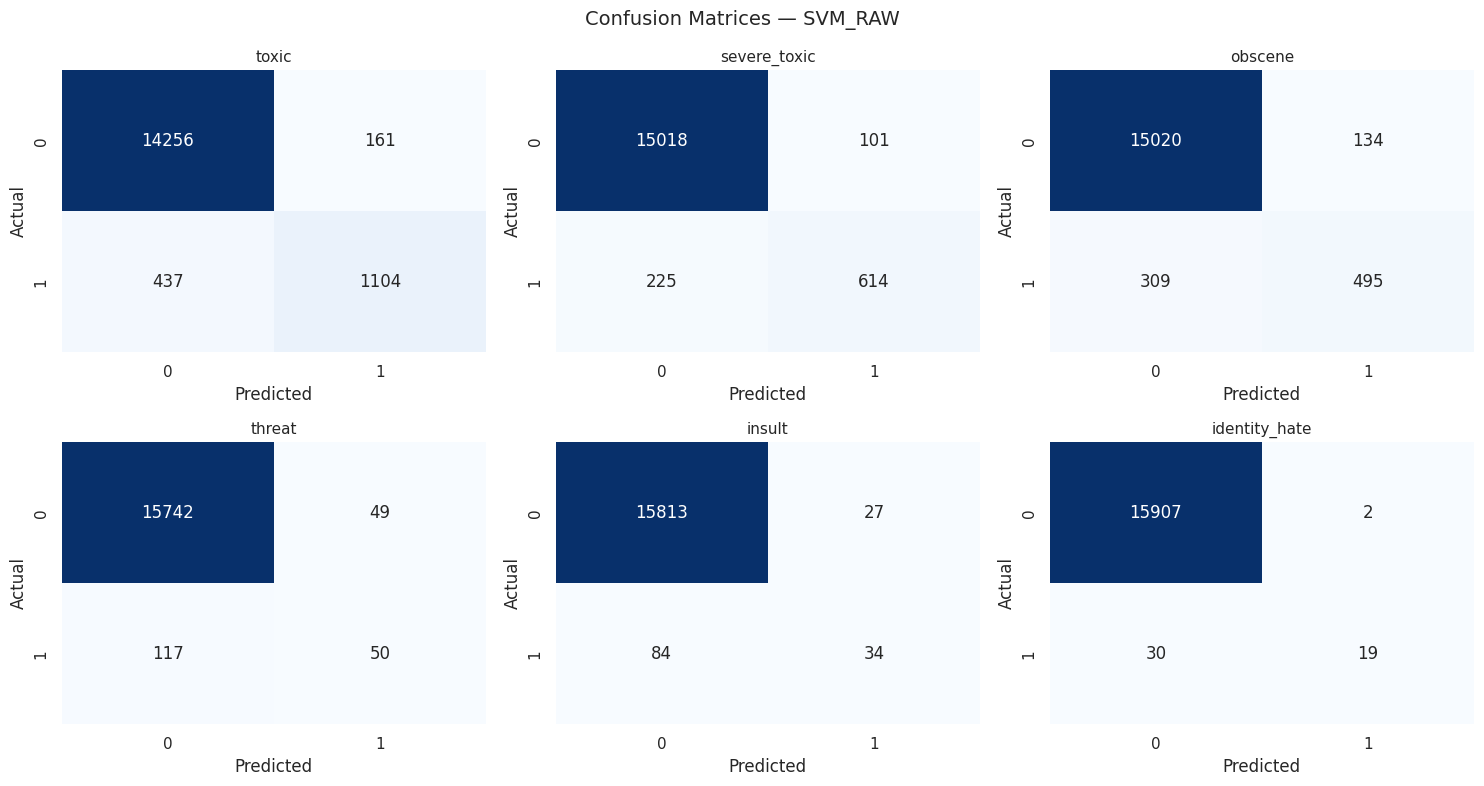

In [86]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

In [93]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


**Advanced clean version**

In [87]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 7.1s


In [88]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 7.1s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 7.1,
 'infer time (s)': 0.0}

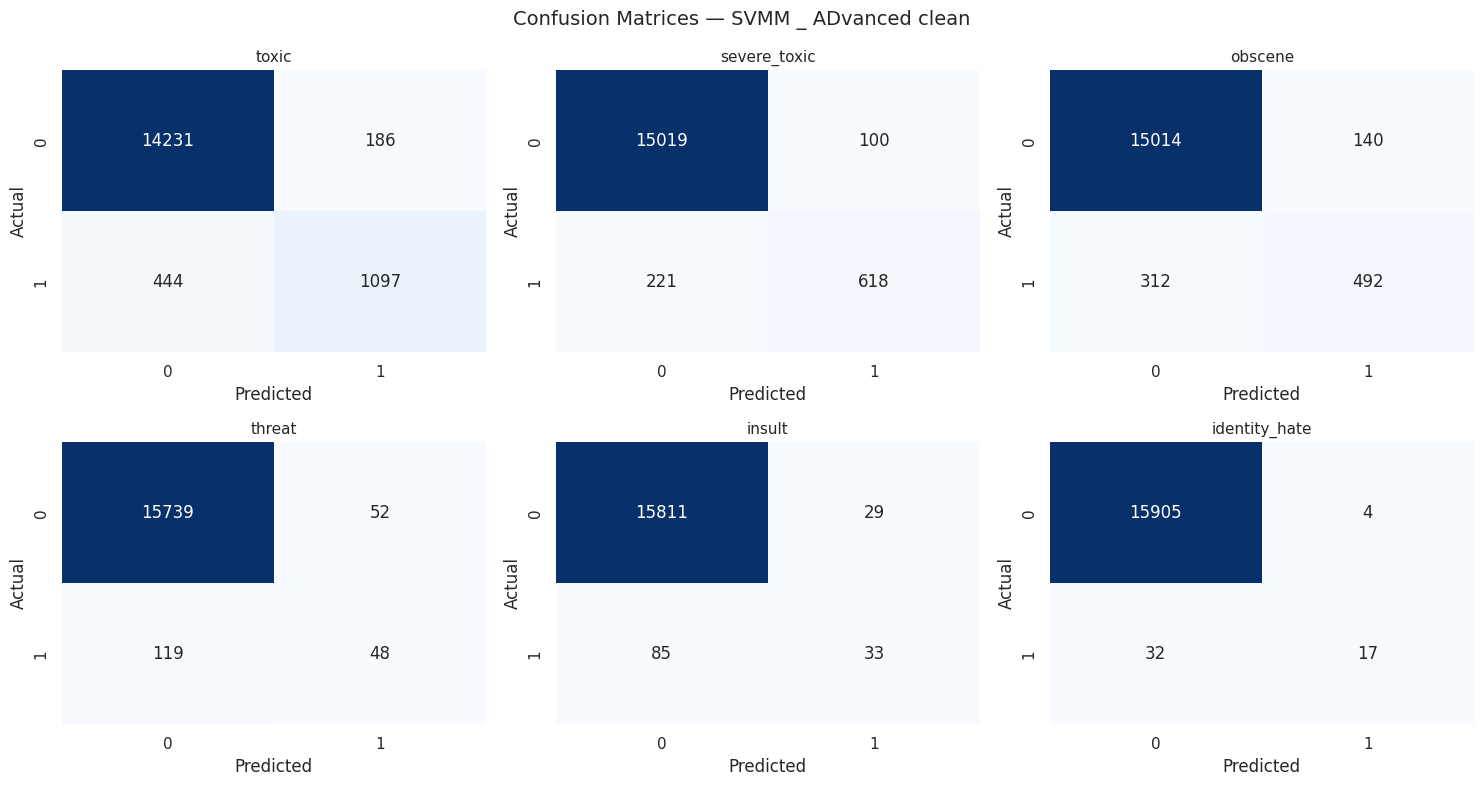

In [89]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

In [109]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

# preprocess
sample_clean = [advanced_preprocess(t) for t in sample_comments]

# tfidf transform
sample_tfidf = tfidf_raw.transform(sample_clean)

# prediction
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


# Model 3 — Bidirectional LSTM

In [108]:
# from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
#                                       Dropout, Bidirectional, GlobalMaxPooling1D)
# vocab_size = len(Tokenizer.word_index) + 1

AttributeError: type object 'Tokenizer' has no attribute 'word_index'

In [106]:
# EMBED_DIM = 128
# NUM_LABELS = len(label_cols)

# def build_bilstm(vocab_size, max_len, num_labels):
#     model = tf.keras.Sequential([
#         Embedding(vocab_size, EMBED_DIM, input_length=max_len, mask_zero=True),

#         Bidirectional(
#             LSTM(128, return_sequences=True,
#                  dropout=0.2,
#                  recurrent_dropout=0.1)
#         ),

#         GlobalMaxPooling1D(),

#         Dense(128, activation='relu'),
#         Dropout(0.3),

#         Dense(num_labels, activation='sigmoid')
#     ])

#     model.compile(
#         optimizer='adam',
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# lstm_model = build_bilstm(vocab_size, max_len, NUM_LABELS)
# lstm_model.summary()

NameError: name 'vocab_size' is not defined